<a href="https://colab.research.google.com/github/Riky-18/Linear_Regression-Task/blob/main/Linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coefficient: 2.7335295398894592
Intercept: 1887152.7393188179
R² Score: 0.6235450247987547
MAE: 57932515.61629188
RMSE: 111589099.54426433

Marketing/Budget = ₹10 crore
Predicted Box Office Revenue = ₹ 275240106.73


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


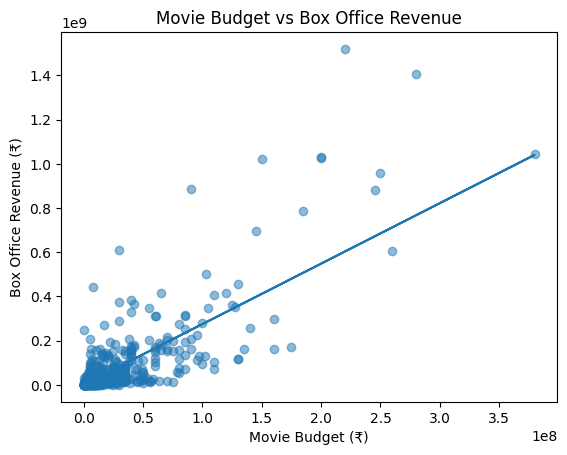

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("train.csv")

# Select required columns
df = df[["budget", "revenue"]]

# Remove movies with zero budget
df = df[df["budget"] > 0]

# Split data
X = df[["budget"]]
y = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction on test data
y_pred = model.predict(X_test)

# Model evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# Predict revenue for ₹10 crore budget
budget_10_crore = 10 * 10_000_000
predicted_revenue = model.predict([[budget_10_crore]])[0]

print("\nMarketing/Budget = ₹10 crore")
print("Predicted Box Office Revenue = ₹", round(predicted_revenue, 2))

# Visualization
plt.scatter(X_test, y_test, alpha=0.5)
plt.plot(X_test, y_pred)
plt.xlabel("Movie Budget (₹)")
plt.ylabel("Box Office Revenue (₹)")
plt.title("Movie Budget vs Box Office Revenue")
plt.show()